# 2 — Tail dependence: why Gaussian copulas are dangerous

This notebook is about one number and the damage it does when you get it wrong.

The **tail dependence coefficient** asks: given one variable has fallen into its worst $q$ of
outcomes, how likely is the other to be there too?

$$\lambda_L(q) = P\big(U_2 < q \mid U_1 < q\big), \qquad \lambda_L = \lim_{q \to 0} \lambda_L(q)$$

Here is the fact that motivates this whole library:

> For a Gaussian copula, $\lambda_L = \lambda_U = 0$ for **every** correlation $\rho < 1$.

A Gaussian copula does not merely underestimate joint extremes — it asserts that, far enough
out, the variables become independent. Fit one to data whose extremes genuinely move together
and it will tell you the joint crash you are worried about is far rarer than it is.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neurocopula import NeuroCopula, datasets, metrics, plotting as ncplot, theme
from neurocopula.marginals import pseudo_observations

pd.set_option("display.width", 130, "display.precision", 4)

# Apply the library's visual theme, so hand-rolled figures in this notebook
# match the ones the library produces. rcParams are read when an Axes is
# created, so this must run before any plotting.
theme.apply_theme()

## Four copulas that share a Kendall's tau

We build four datasets with **identical rank correlation** ($\tau = 0.5$) but completely
different tail behaviour. Anything that summarises dependence with a single correlation
number cannot tell these apart.

In [2]:
N = 40_000
cases = {
    "Gaussian":   (datasets.make_gaussian_copula(n=N, rho=0.707, marginals="uniform", seed=0),
                   datasets.theoretical_tail_dependence("gaussian", rho=0.707)),
    "Student-t":  (datasets.make_t_copula(n=N, rho=0.707, dof=4, marginals="uniform", seed=0),
                   datasets.theoretical_tail_dependence("t", rho=0.707, df=4)),
    "Clayton":    (datasets.make_clayton(n=N, theta=2.0, marginals="uniform", seed=0),
                   datasets.theoretical_tail_dependence("clayton", theta=2.0)),
    "Gumbel":     (datasets.make_gumbel(n=N, theta=2.0, marginals="uniform", seed=0),
                   datasets.theoretical_tail_dependence("gumbel", theta=2.0)),
}

rows = []
for name, (data, truth) in cases.items():
    rows.append({
        "copula": name,
        "Kendall tau": metrics.kendall_tau_matrix(data).iloc[0, 1],
        "lambda_L (q=0.01)": metrics.tail_dependence(data.x1, data.x2, q=0.01, tail="lower"),
        "lambda_U (q=0.01)": metrics.tail_dependence(data.x1, data.x2, q=0.01, tail="upper"),
        "true lambda_L": truth["lower"],
        "true lambda_U": truth["upper"],
    })
pd.DataFrame(rows).set_index("copula").round(3)

,Kendall tau,lambda_L (q=0.01),lambda_U (q=0.01),true lambda_L,true lambda_U
copula,,,,,
Gaussian,0.501,0.302,0.272,0.000,0.000
Student-t,0.503,0.450,0.400,0.397,0.397
Clayton,0.497,0.722,0.018,0.707,0.000
Gumbel,0.500,0.130,0.545,0.000,0.586


Every row has essentially the same Kendall's tau. The tail columns are wildly different:
Clayton concentrates its dependence in the lower tail, Gumbel in the upper, Student-t in both,
Gaussian in neither. **Correlation tells you nothing about this.**

Note that the Gaussian row does not show exactly zero at $q = 0.01$. That is correct and
important: $\lambda = 0$ is an *asymptotic* statement. At any finite $q$ a correlated Gaussian
still shows co-movement; it just decays to nothing as you go further out. A single number at
one $q$ cannot reveal that — which is why the curve matters.

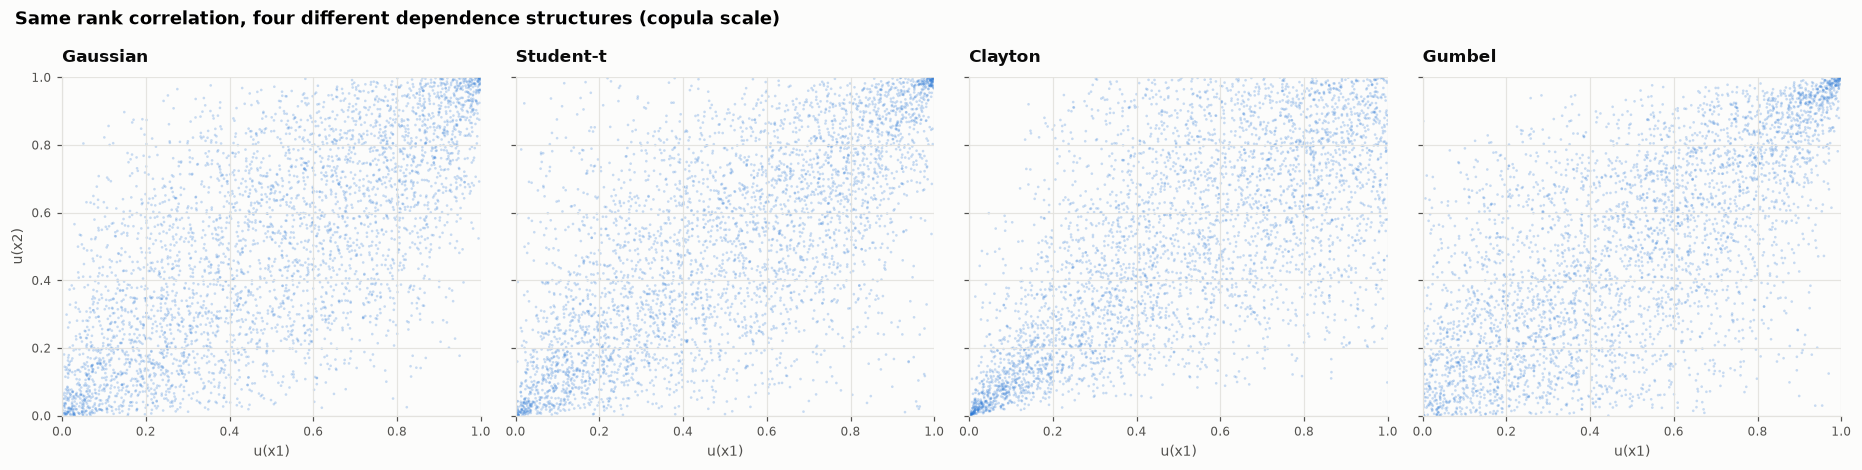

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.3), sharex=True, sharey=True)
for ax, (name, (data, _)) in zip(axes, cases.items()):
    sub = data.iloc[:4000]
    ax.scatter(sub.x1, sub.x2, s=3, alpha=0.25, color="#2a78d6", edgecolors="none")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(name); ax.set_xlabel("u(x1)")
axes[0].set_ylabel("u(x2)")
fig.suptitle("Same rank correlation, four different dependence structures (copula scale)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

On the copula scale the marginals are uniform by construction, so every visible feature is
dependence. Clayton crowds the bottom-left corner; Gumbel the top-right; Student-t both;
Gaussian is an even ellipse with no corner concentration.

## The diagnostic that actually works: $\lambda(q)$ as a curve

Plot $\lambda$ against $q$ on a log axis and the distinction becomes unmissable. Read it by
**shape**, not level:

- **Sloping toward zero** as $q$ shrinks → asymptotic independence. The pair decouples in the
  extreme.
- **Flattening onto a positive plateau** → genuine tail dependence. The pair keeps moving
  together however far out you look.

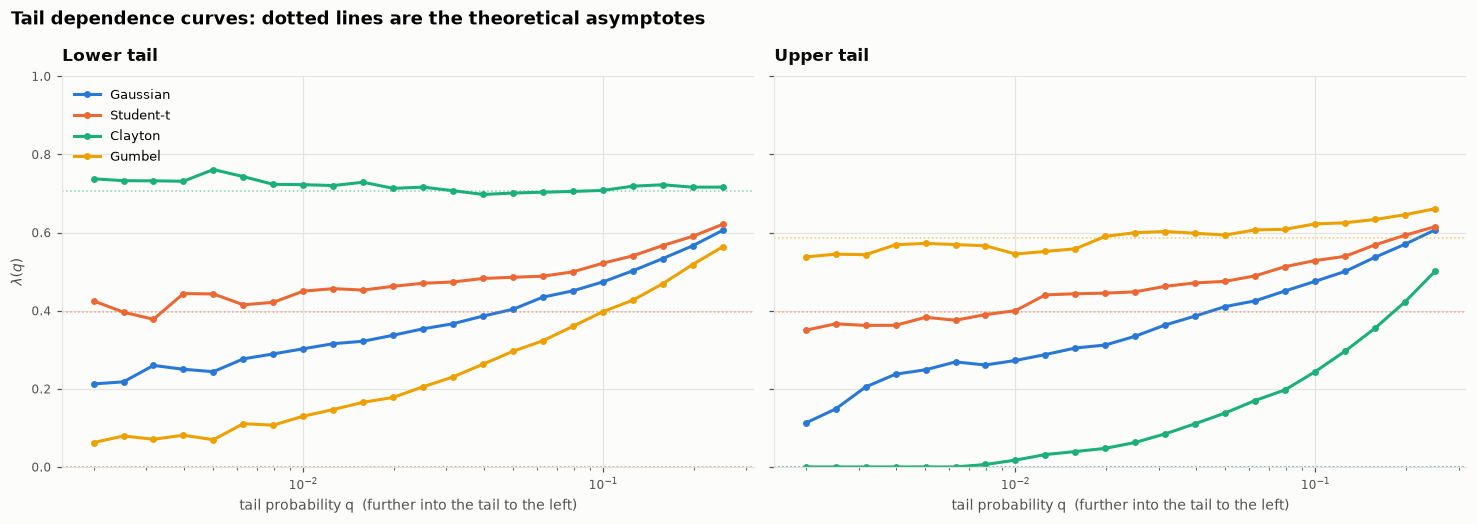

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)
quantiles = np.geomspace(0.002, 0.25, 22)
colors = {"Gaussian": "#2a78d6", "Student-t": "#eb6834", "Clayton": "#1baf7a", "Gumbel": "#eda100"}

for tail, ax in zip(["lower", "upper"], axes):
    for name, (data, truth) in cases.items():
        curve = metrics.tail_dependence_curve(data.x1, data.x2, quantiles=quantiles, tail=tail)
        ax.plot(curve["q"], curve["lambda"], marker="o", markersize=3.5,
                color=colors[name], label=name)
        ax.axhline(truth[tail], color=colors[name], ls=":", lw=1, alpha=0.55)
    ax.set_xscale("log"); ax.set_ylim(0, 1)
    ax.set_xlabel("tail probability q  (further into the tail to the left)")
    ax.set_title(f"{tail.capitalize()} tail")
axes[0].set_ylabel(r"$\lambda(q)$"); axes[0].legend(loc="upper left")
fig.suptitle("Tail dependence curves: dotted lines are the theoretical asymptotes",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout(); plt.show()

The Gaussian curve slides steadily toward zero in both panels — that is asymptotic
independence made visible. Clayton plateaus near 0.71 on the left and collapses on the right.
Gumbel does the reverse. Student-t plateaus on both.

## Can the flow learn these shapes?

The real test. We fit a `NeuroCopula` to each dataset — with no hint about which family
generated it — and check whether it reproduces the right curve.

In [5]:
fitted = {}
for name, (data, _) in cases.items():
    train = data.iloc[:8000]
    fitted[name] = NeuroCopula(
        transforms=4, hidden_features=(64, 64), copula_mode=True, seed=0,
    ).fit(train, epochs=600, patience=60, split_method="random", verbose=False)
    print(f"fitted {name:11s}  best_epoch={fitted[name].best_epoch:4d}  "
          f"overfit_gap={fitted[name].fit_report_['overfit_gap']:+.3f}")

fitted Gaussian     best_epoch=  40  overfit_gap=+0.005


fitted Student-t    best_epoch=  92  overfit_gap=-0.017


fitted Clayton      best_epoch=  69  overfit_gap=+0.020


fitted Gumbel       best_epoch=  67  overfit_gap=+0.006


In [6]:
rows = []
for name, (data, truth) in cases.items():
    m = fitted[name]
    u = m.sample_uniform(200_000)
    rows.append({
        "copula": name,
        "true lambda_L": truth["lower"],
        "model lambda_L": metrics.tail_dependence(u.x1, u.x2, q=0.02, tail="lower"),
        "true lambda_U": truth["upper"],
        "model lambda_U": metrics.tail_dependence(u.x1, u.x2, q=0.02, tail="upper"),
    })
result = pd.DataFrame(rows).set_index("copula")
result["asymmetry (true)"] = result["true lambda_L"] - result["true lambda_U"]
result["asymmetry (model)"] = result["model lambda_L"] - result["model lambda_U"]
result.round(3)

,true lambda_L,model lambda_L,true lambda_U,model lambda_U,asymmetry (true),asymmetry (model)
copula,,,,,,
Gaussian,0.000,0.220,0.000,0.377,0.000,-0.157
Student-t,0.397,0.468,0.397,0.472,0.000,-0.004
Clayton,0.707,0.706,0.000,0.075,0.707,0.632
Gumbel,0.000,0.162,0.586,0.610,-0.586,-0.448


The **asymmetry** columns are the ones to read. The model gets the sign and rough magnitude
right in every case: strongly positive for Clayton (0.63 against a true 0.71), strongly
negative for Gumbel, and much smaller in magnitude for the two elliptical copulas. It learned
*which tail matters* without being told the family.

Two honest caveats. Values at $q = 0.02$ do not equal the asymptotic truth and should not —
$\lambda$ is a limit as $q \to 0$, and at any positive $q$ even a perfect model shows a
finite value. And the Gaussian row's asymmetry is not exactly zero: at this $q$, with a
finite fit, some residual asymmetry is sampling noise rather than learned structure. What
matters is that it is several times smaller than the genuine asymmetries above it.

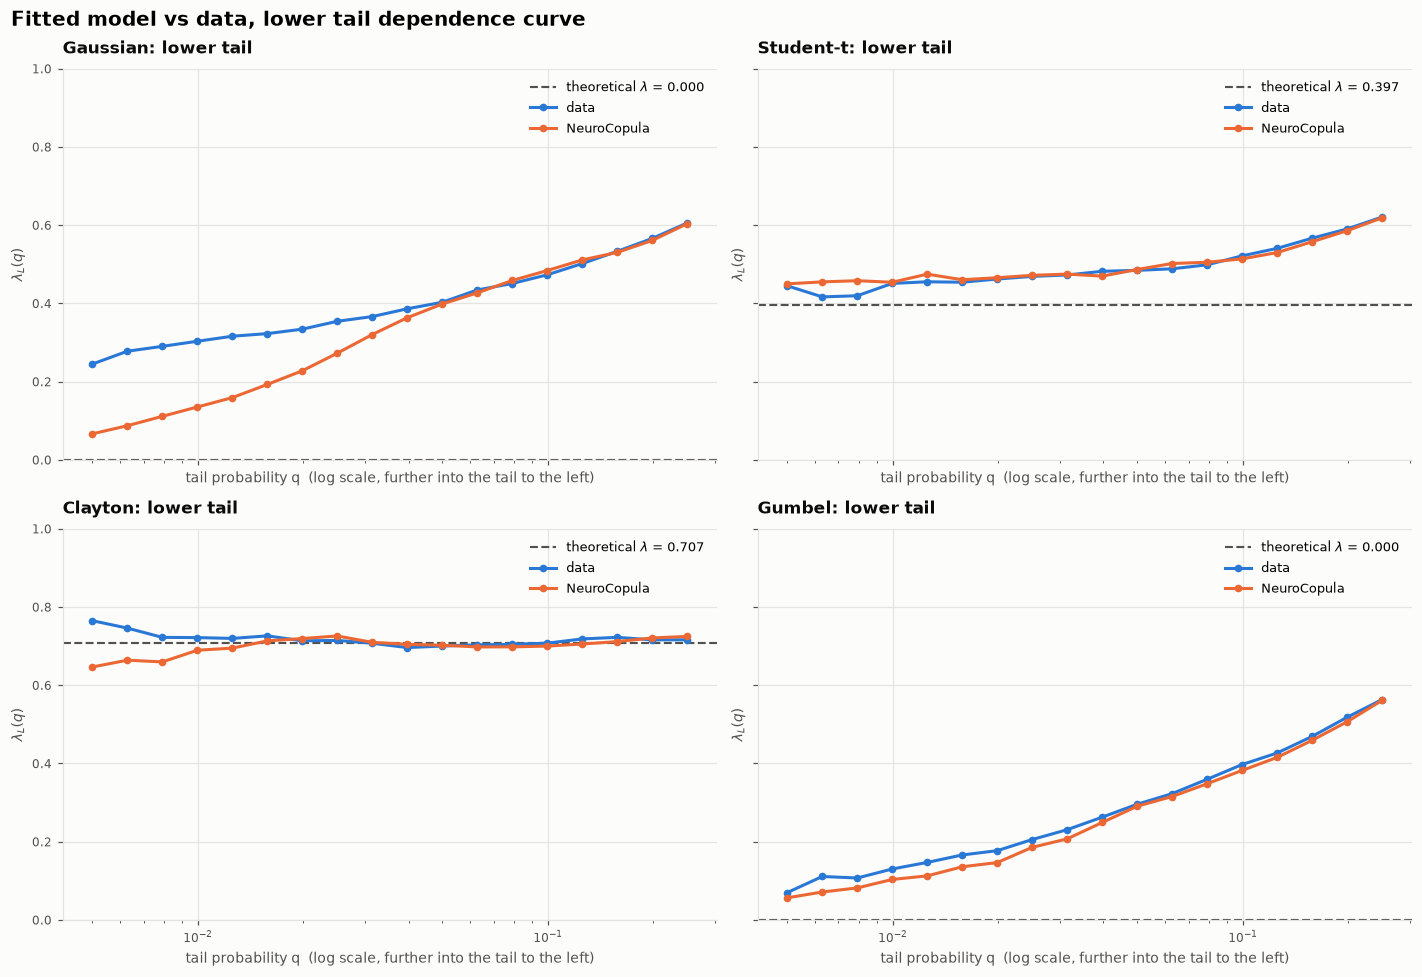

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (name, (data, truth)) in zip(axes.ravel(), cases.items()):
    frames = {"data": data, "NeuroCopula": fitted[name].sample_uniform(60_000)}
    ncplot.plot_tail_dependence_curve(frames, "x1", "x2", tail="lower",
                                      theoretical=truth["lower"],
                                      quantiles=np.geomspace(0.005, 0.25, 18), ax=ax)
    ax.set_title(f"{name}: lower tail")
fig.suptitle("Fitted model vs data, lower tail dependence curve",
             x=0.01, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout(); plt.show()

## What it costs to get this wrong

Abstract coefficients are easy to shrug off, so let us price the error. We fit a **Gaussian
copula** to Clayton data — the classic mistake — and compare the joint crash probabilities it
reports against the truth.

The Gaussian copula is built here as a vine restricted to the Gaussian family, which is
exactly what "assume a Gaussian copula" means in practice.

In [8]:
from neurocopula import VineCopula

clayton = datasets.make_clayton(n=8000, theta=2.0, marginals="t", df=4, seed=0)

flow     = NeuroCopula(transforms=4, hidden_features=(64, 64), seed=0).fit(
    clayton, epochs=600, patience=60, split_method="random", verbose=False)
gaussian = VineCopula(family_set="gaussian").fit(clayton)
flexible = VineCopula(family_set="parametric").fit(clayton)

print("vine family chosen when restricted to Gaussian :", gaussian.pair_families()[0][0])
print("vine family chosen from the full set           :", flexible.pair_families()[0][0])

vine family chosen when restricted to Gaussian : gaussian
vine family chosen from the full set           : clayton


In [9]:
thresholds = [-1.5, -2.0, -2.5, -3.0]
rows = []
for t in thresholds:
    conditions = {"x1": ("<", t), "x2": ("<", t)}
    empirical = float(((clayton.x1 < t) & (clayton.x2 < t)).mean())
    rows.append({
        "threshold": t,
        "empirical": empirical,
        "NeuroCopula": flow.joint_exceedance_probability(conditions, n_mc=400_000),
        "Vine (Gaussian only)": gaussian.joint_exceedance_probability(conditions, n_mc=400_000),
        "Vine (full set)": flexible.joint_exceedance_probability(conditions, n_mc=400_000),
    })
risk = pd.DataFrame(rows).set_index("threshold")
risk["Gaussian understates by"] = (risk["empirical"] / risk["Vine (Gaussian only)"]).round(1)
risk.round(5)

,empirical,NeuroCopula,Vine (Gaussian only),Vine (full set),Gaussian understates by
threshold,,,,,
-1.5,0.0739,0.0768,0.0480,0.0738,1.5
-2.0,0.0411,0.0424,0.0221,0.0404,1.9
-2.5,0.0221,0.0242,0.0107,0.0227,2.1
-3.0,0.0140,0.0148,0.0054,0.0133,2.6


The final column is the punchline: the Gaussian-copula model understates the probability of a
joint crash by a growing multiple as the threshold gets more extreme. That is the wrong
direction to be wrong in — the error is largest exactly where the consequences are worst.

## Takeaways

1. **Kendall's tau cannot distinguish these copulas.** Four datasets, one rank correlation,
   four different tail behaviours.
2. **Read $\lambda$ as a curve, not a number.** The shape as $q \to 0$ is what separates
   asymptotic independence from genuine tail dependence.
3. **A Gaussian copula asserts zero tail dependence.** On data that has it, the model
   understates joint extremes, and by more the further out you look.
4. **The flow recovers the right shape without being told the family** — including the
   asymmetry that no elliptical copula can represent.
5. **A flexible vine also handles these**, since Clayton and Gumbel are in its candidate set.
   The flow's advantage shows up when *no* standard family fits — see notebook 06 and the
   benchmark suite.